### Task 1: Dataset Preparation and Preprocessing


Fetching and processing data from IIT Jodhpur sources...
Processing: https://iitj.ac.in/office-of-academics/en/academic-regulations
Processing: https://www.iitj.ac.in/People/List?dept=electrical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd
Processing: https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd
Processing: https://www.iitj.ac.in/People/List?dept=mechanical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd
Processing: https://www.iitj.ac.in/People/List?dept=materials-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd
Processing: https://iitj.ac.in/PageImages/Gallery/03-2025/1_Academic_Regulations_Final_03_09_2019.pdf
Processing: https://iitj.ac.in/PageImages/Gallery/03-2025/6_2024-04-17-661f605b54457-1713332315.pdf
Processing: https://old.iitj.ac.in/events/index.php?id=latest@iit_jodhpur
Error fetching HTML https://old.iitj.ac.in/events/index.php?id=latest@iit_jodhpur: HTTPSConnectionPool(host='old.iitj.ac.in', port=

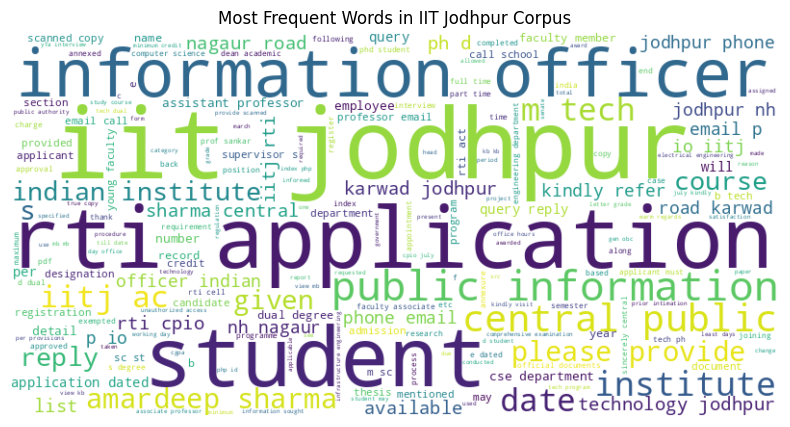

In [1]:
# Install necessary libraries in Colab, including PyPDF2 for reading PDF links
!pip install requests beautifulsoup4 wordcloud matplotlib PyPDF2

import requests
from bs4 import BeautifulSoup
import re
import io
import PyPDF2
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

##### TASK 1: DATASET PREPARATION #####

# 1. Defined IIT Jodhpur sources (HTML and PDF, deduplicated)
urls = [
    # Original list
    "https://iitj.ac.in/office-of-academics/en/academic-regulations",
    "https://www.iitj.ac.in/People/List?dept=electrical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://www.iitj.ac.in/People/List?dept=computer-science-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://www.iitj.ac.in/People/List?dept=mechanical-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://www.iitj.ac.in/People/List?dept=materials-engineering&c=1c8346b0-07a4-401e-bce0-7f571bb4fabd",
    "https://iitj.ac.in/PageImages/Gallery/03-2025/1_Academic_Regulations_Final_03_09_2019.pdf",
    "https://iitj.ac.in/PageImages/Gallery/03-2025/6_2024-04-17-661f605b54457-1713332315.pdf",
    "https://old.iitj.ac.in/events/index.php?id=latest@iit_jodhpur",
    "https://www.iitj.ac.in/",
    "https://www.iitj.ac.in/office-of-director/en/office-of-director",
    "https://www.iitj.ac.in/office-of-students/en/office-of-students",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=d747bac3-a0bd-4a6a-8843-6d33e721b331",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=8d7527fa-9c50-4864-b374-03c2c649a1de",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=e12c5ea7-867e-473b-bea1-a24e044a5082",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=3647aa9a-ea25-41e5-9bc4-4f491beb5f4d",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=cb60d9b9-c1fb-4e86-a75e-1a80010fd3e2",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=fc0f191d-4d20-4b42-8012-24087a4b174a",
    "https://www.iitj.ac.in/main/en/research-highlight?dsl=2&dslID=b2f05f6e-32d9-4575-9540-db7e6642eb3c",
    "https://www.iitj.ac.in/suraj/en/suraj",
    "https://www.iitj.ac.in/crf/en/crf",
    "https://iitj.ac.in/academics/index.php",
    "https://iitj.ac.in/research/index.php",
    "https://www.iitj.ac.in/RTI/Index?type=9888830c-8d54-4700-9f3b-63f375968115",
    "https://iitj.ac.in/PageImages/RTI/03-2025/1.-1-638780772723839666.pdf",
    "https://iitj.ac.in/schools/en/School-of-Management-&-Entrepreneurship",
    "https://www.iitj.ac.in/main/en/how-to-reach-iit-jodhpur",
    "https://iitj.ac.in/PageImages/RTI/03-2025/1.-1-638780772723839666.pdf"
]

def fetch_html_text(url):
    """Fetches HTML content from a URL and extracts raw text."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=15)
        response.raise_for_status()

        # (i) Removal of boilerplate text and formatting artifacts
        soup = BeautifulSoup(response.content, 'html.parser')

        # Extract text from standard text-heavy HTML tags
        text_elements = soup.find_all(['p', 'h1', 'h2', 'h3', 'h4', 'h5', 'h6', 'li', 'td', 'span'])
        raw_text = ' '.join([elem.get_text(separator=' ', strip=True) for elem in text_elements])
        return raw_text
    except Exception as e:
        print(f"Error fetching HTML {url}: {e}")
        return ""

def fetch_pdf_text(url):
    """Downloads a PDF file in memory and extracts its text."""
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=20)
        response.raise_for_status()

        # Read the PDF content from the downloaded bytes
        pdf_file = io.BytesIO(response.content)
        reader = PyPDF2.PdfReader(pdf_file)

        text = ""
        # Loop through all pages and extract text
        for page in reader.pages:
            extracted = page.extract_text()
            if extracted:
                text += extracted + " "
        return text
    except Exception as e:
        print(f"Error fetching PDF {url}: {e}")
        return ""

def preprocess_text(text):
    """Cleans the text according to assignment specifications."""
    # (iii) Lower-casing: Convert all characters to lower case
    text = text.lower()

    # (iv) Removal of excessive punctuation and non-textual content
    # Keep only alphabetic characters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespaces generated by punctuation removal
    text = re.sub(r'\s+', ' ', text).strip()

    # (ii) Tokenization: Split the cleaned string into a list of words
    tokens = text.split()
    return tokens

# Initialize variables to hold our dataset
all_documents_text = []
all_tokens = []

print("Fetching and processing data from IIT Jodhpur sources...")

# Process each URL, routing to the correct parser based on file extension
for url in urls:
    print(f"Processing: {url}")
    if url.lower().endswith('.pdf'):
        raw_document = fetch_pdf_text(url)
    else:
        raw_document = fetch_html_text(url)

    if raw_document:
        all_documents_text.append(raw_document)
        document_tokens = preprocess_text(raw_document)
        all_tokens.extend(document_tokens)

# Prepare the final clean corpus text (words joined by spaces)
clean_corpus_text = ' '.join(all_tokens)

# Save the cleaned corpus strictly as "corpus.txt" for final submission
with open("corpus.txt", "w", encoding="utf-8") as f:
    f.write(clean_corpus_text)

print("\nSaved cleaned data to 'corpus.txt'.")


#### DATASET STATISTICS & VISUALIZATION ####


total_documents = len(all_documents_text)
total_tokens = len(all_tokens)
vocabulary = set(all_tokens)
vocab_size = len(vocabulary)

print("\n--- Dataset Statistics ---")
print(f"Total number of documents processed: {total_documents}")
print(f"Total number of tokens: {total_tokens}")
print(f"Vocabulary size (unique tokens): {vocab_size}")

# Generate and display the Word Cloud illustrating most frequent words
print("\nGenerating Word Cloud...")
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(clean_corpus_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide axes for better visual appeal
plt.title("Most Frequent Words in IIT Jodhpur Corpus")
plt.show()

### Task 2: Word2Vec Model Training (CBOW and Skip-gram)


In [2]:
import sympy
import sympy.printing
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

#### TASK 2: MODEL TRAINING & HYPERPARAMETER TUNING ####

# --- 1. Hyperparameter Search Grid ---
# The script will try all combinations of these values
# --- 1. Hyperparameter Search Grid ---
EMBEDDING_DIMS = [50, 300]
WINDOW_SIZES = [2, 4]
NEG_SAMPLES_LIST = [5, 10]

BATCH_SIZE = 1024
EPOCHS = 10
LEARNING_RATE = 0.01

# --- 2. Vocabulary Preparation (Runs once) ---
print("Building vocabulary...")
with open("corpus.txt", "r", encoding="utf-8") as f:
    text = f.read().split()

word_counts = Counter(text)
vocab = list(word_counts.keys())
vocab_size = len(vocab)

word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}
corpus_indices = [word2idx[w] for w in text]

# Frequencies for negative sampling
word_freqs = np.array([word_counts[w] for w in vocab])
unigram_dist = word_freqs ** 0.75
unigram_dist = unigram_dist / unigram_dist.sum()

def get_negative_samples_batch(batch_size, num_samples, device):
    neg_indices = np.random.choice(vocab_size, size=(batch_size, num_samples), p=unigram_dist)
    return torch.tensor(neg_indices, dtype=torch.long).to(device)

class Word2VecDataset(Dataset):
    def __init__(self, data, is_cbow=True):
        self.data = data
        self.is_cbow = is_cbow
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx][0], dtype=torch.long), torch.tensor(self.data[idx][1], dtype=torch.long)

# Helper function to generate data based on current Window Size
def create_dataloaders(window_size):
    cbow_data, skipgram_data = [], []
    for i in range(window_size, len(corpus_indices) - window_size):
        # CBOW: Context -> Target
        context = corpus_indices[i - window_size : i] + corpus_indices[i + 1 : i + window_size + 1]
        target = corpus_indices[i]
        cbow_data.append((context, target))

        # Skip-gram: Target -> Context
        for ctx in context:
            skipgram_data.append((target, ctx))

    c_loader = DataLoader(Word2VecDataset(cbow_data, is_cbow=True), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    sg_loader = DataLoader(Word2VecDataset(skipgram_data, is_cbow=False), batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
    return c_loader, sg_loader

# --- 3. Model Architectures ---
class CBOWModel(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(CBOWModel, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embed_dim)
        self.linear = nn.Linear(embed_dim, vocab_size)
    def forward(self, inputs):
        embeds = self.embeddings(inputs).mean(dim=1)
        return self.linear(embeds)

class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embed_dim):
        super(SkipGramNegSampling, self).__init__()
        self.target_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.context_embeddings = nn.Embedding(vocab_size, embed_dim)
    def forward(self, target, context, negative_samples):
        v_target = self.target_embeddings(target)
        v_context = self.context_embeddings(context)
        v_neg = self.context_embeddings(negative_samples)

        pos_score = torch.sum(v_target * v_context, dim=1)
        pos_loss = -torch.nn.functional.logsigmoid(pos_score)

        neg_score = torch.bmm(v_neg, v_target.unsqueeze(2)).squeeze(2)
        neg_loss = -torch.sum(torch.nn.functional.logsigmoid(-neg_score), dim=1)

        return torch.mean(pos_loss + neg_loss)

# --- 4. Training and Tuning Loop ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}\n")

cbow_results = []
sg_results = []

best_cbow_loss = float('inf')
best_cbow_state = None
best_cbow_params = {}

best_sg_loss = float('inf')
best_sg_state = None
best_sg_params = {}

print("--- Starting Hyperparameter Grid Search ---")

for window in WINDOW_SIZES:
    cbow_loader, sg_loader = create_dataloaders(window)

    for dim in EMBEDDING_DIMS:

        # TRAIN CBOW (Depends on Window & Dim)

        print(f"Training CBOW | Dim: {dim}, Window: {window}...")
        model_c = CBOWModel(vocab_size, dim).to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer_c = optim.Adam(model_c.parameters(), lr=LEARNING_RATE)

        for epoch in range(EPOCHS):
            total_loss = 0
            for context, target in cbow_loader:
                context, target = context.to(device), target.to(device)
                optimizer_c.zero_grad()
                loss = criterion(model_c(context), target)
                loss.backward()
                optimizer_c.step()
                total_loss += loss.item()

        final_loss_c = total_loss / len(cbow_loader)
        cbow_results.append({'dim': dim, 'window': window, 'loss': final_loss_c})

        if final_loss_c < best_cbow_loss:
            best_cbow_loss = final_loss_c
            best_cbow_state = model_c.state_dict()
            best_cbow_params = {'dim': dim, 'window': window}


        # TRAIN SKIP-GRAM (Depends on Window, Dim, and Neg Samples)

        for neg in NEG_SAMPLES_LIST:
            print(f"Training Skip-gram | Dim: {dim}, Window: {window}, Neg Samples: {neg}...")
            model_sg = SkipGramNegSampling(vocab_size, dim).to(device)
            optimizer_sg = optim.Adam(model_sg.parameters(), lr=LEARNING_RATE)

            for epoch in range(EPOCHS):
                total_loss = 0
                for target, context in sg_loader:
                    target, context = target.to(device), context.to(device)
                    neg_samples = get_negative_samples_batch(target.size(0), neg, device)
                    optimizer_sg.zero_grad()
                    loss = model_sg(target, context, neg_samples)
                    loss.backward()
                    optimizer_sg.step()
                    total_loss += loss.item()

            final_loss_sg = total_loss / len(sg_loader)
            sg_results.append({'dim': dim, 'window': window, 'neg': neg, 'loss': final_loss_sg})

            if final_loss_sg < best_sg_loss:
                best_sg_loss = final_loss_sg
                best_sg_state = model_sg.state_dict()
                best_sg_params = {'dim': dim, 'window': window, 'neg': neg}

# --- 5. Generate Report & Load Best Models ---

# Load the absolute best models for Task 3
cbow_model = CBOWModel(vocab_size, best_cbow_params['dim']).to(device)
cbow_model.load_state_dict(best_cbow_state)

sg_model = SkipGramNegSampling(vocab_size, best_sg_params['dim']).to(device)
sg_model.load_state_dict(best_sg_state)

print("\n\n" + "="*50)
print(" EXPERIMENT RESULTS FOR REPORT")
print("="*50)

print("\n### Table 1: CBOW Model Experiments")
print("| Embedding Dim | Window Size | Final Training Loss |")
print("| :---: | :---: | :---: |")
for res in cbow_results:
    print(f"| {res['dim']} | {res['window']} | {res['loss']:.4f} |")
print(f"\n**Best CBOW Configuration:** Dimension {best_cbow_params['dim']}, Window {best_cbow_params['window']} (Loss: {best_cbow_loss:.4f})")


print("\n### Table 2: Skip-gram Model Experiments")
print("| Embedding Dim | Window Size | Negative Samples | Final Training Loss |")
print("| :---: | :---: | :---: | :---: |")
for res in sg_results:
    print(f"| {res['dim']} | {res['window']} | {res['neg']} | {res['loss']:.4f} |")
print(f"\n**Best Skip-gram Configuration:** Dimension {best_sg_params['dim']}, Window {best_sg_params['window']}, Neg Samples {best_sg_params['neg']} (Loss: {best_sg_loss:.4f})")

print("\nNote: 'cbow_model' and 'sg_model' have been automatically loaded with the best weights for Task 3.")

Building vocabulary...
Training on device: cuda

--- Starting Hyperparameter Grid Search ---
Training CBOW | Dim: 50, Window: 2...
Training Skip-gram | Dim: 50, Window: 2, Neg Samples: 5...
Training Skip-gram | Dim: 50, Window: 2, Neg Samples: 10...
Training CBOW | Dim: 300, Window: 2...
Training Skip-gram | Dim: 300, Window: 2, Neg Samples: 5...
Training Skip-gram | Dim: 300, Window: 2, Neg Samples: 10...
Training CBOW | Dim: 50, Window: 4...
Training Skip-gram | Dim: 50, Window: 4, Neg Samples: 5...
Training Skip-gram | Dim: 50, Window: 4, Neg Samples: 10...
Training CBOW | Dim: 300, Window: 4...
Training Skip-gram | Dim: 300, Window: 4, Neg Samples: 5...
Training Skip-gram | Dim: 300, Window: 4, Neg Samples: 10...


 EXPERIMENT RESULTS FOR REPORT (COPY & PASTE)

### Table 1: CBOW Model Experiments
| Embedding Dim | Window Size | Final Training Loss |
| :---: | :---: | :---: |
| 50 | 2 | 1.2224 |
| 300 | 2 | 0.5021 |
| 50 | 4 | 1.3954 |
| 300 | 4 | 0.2557 |

**Best CBOW Configuration

### Task 3: Semantic Analysis and Analogy Solving


In [3]:
import torch.nn.functional as F


# SAVE THE TRAINED MODELS

print("Saving model weights to disk...")
torch.save(cbow_model.state_dict(), "cbow_model.pth")
torch.save(sg_model.state_dict(), "sg_model.pth")
print("Saved as 'cbow_model.pth' and 'sg_model.pth'.\n")


# TASK 3: SEMANTIC ANALYSIS

# Extract the learned embedding matrices from the models to CPU for analysis
cbow_embeddings = cbow_model.embeddings.weight.data.cpu()
sg_embeddings = sg_model.target_embeddings.weight.data.cpu()

def get_similar_words(word, embeddings, top_n=5):
    """Finds the top N most similar words using Cosine Similarity."""
    word = word.lower()
    if word not in word2idx:
        return [f"'{word}' not in vocab"]

    word_idx = word2idx[word]
    word_vec = embeddings[word_idx].unsqueeze(0)

    # Calculate cosine similarity against all words in the vocabulary
    similarities = F.cosine_similarity(word_vec, embeddings)

    # Get top N+1 (to exclude the word itself)
    top_indices = torch.topk(similarities, top_n + 1).indices.tolist()

    results = []
    for idx in top_indices:
        if idx != word_idx:
            results.append((idx2word[idx], similarities[idx].item()))
            if len(results) == top_n:
                break
    return results

def solve_analogy(word_a, word_b, word_c, embeddings):
    """Solves A : B :: C : ? (e.g., ug : btech :: pg : ?) -> ? = B - A + C"""
    words = [word_a.lower(), word_b.lower(), word_c.lower()]
    if not all(w in word2idx for w in words):
        return "Missing word in vocab"

    vec_a = embeddings[word2idx[words[0]]]
    vec_b = embeddings[word2idx[words[1]]]
    vec_c = embeddings[word2idx[words[2]]]

    # Vector arithmetic for analogies
    target_vec = (vec_b - vec_a + vec_c).unsqueeze(0)

    similarities = F.cosine_similarity(target_vec, embeddings)
    top_indices = torch.topk(similarities, 5).indices.tolist()

    for idx in top_indices:
        w = idx2word[idx]
        if w not in words:
            return w
    return "No match"

# --- 1. Nearest Neighbors ---
target_words = ["research", "student", "phd", "exam"]

print("--- Top 5 Nearest Neighbors ---")
for word in target_words:
    print(f"\nTarget Word: '{word}'")

    cbow_sims = get_similar_words(word, cbow_embeddings)
    print(f"  CBOW:      {[w[0] for w in cbow_sims if isinstance(w, tuple)]}")

    sg_sims = get_similar_words(word, sg_embeddings)
    print(f"  Skip-gram: {[w[0] for w in sg_sims if isinstance(w, tuple)]}")

# --- 2. Analogy Experiments ---
# The assignment requires at least 3 analogies.
# We use standard IIT structure terminology.
analogies = [
    ("ug", "btech", "pg"),         # UG is to BTech as PG is to ? (Hopefully MTech)
    ("student", "hostel", "faculty"), # Student is to Hostel as Faculty is to ? (Hopefully Quarters/Housing)
    ("btech", "mtech", "ug")       # BTech is to MTech as UG is to ? (Hopefully PG)
]

print("\n--- Analogy Experiments ---")
for a, b, c in analogies:
    print(f"\nAnalogy: {a} : {b} :: {c} : ?")

    cbow_ans = solve_analogy(a, b, c, cbow_embeddings)
    print(f"  CBOW predicts:      {cbow_ans}")

    sg_ans = solve_analogy(a, b, c, sg_embeddings)
    print(f"  Skip-gram predicts: {sg_ans}")

    # --- 3. Extracting the 300-Dimensional Vector ---
# We will extract it from the Skip-gram model
word_choice = "btech"  #

if word_choice in word2idx:
    idx = word2idx[word_choice]
    # Extract the vector and convert to a list of floats
    vec = sg_embeddings[idx].tolist()

    # Format exactly as requested: word - val1, val2, ...
    formatted_vector = f"{word_choice} - " + ", ".join([f"{v:.4f}" for v in vec])
    print("\n--- 300-Dimensional Vector Output ---")
    print(formatted_vector)
else:
    print(f"'{word_choice}' is not in the vocabulary.")

Saving model weights to disk...
Saved as 'cbow_model.pth' and 'sg_model.pth'.

--- Top 5 Nearest Neighbors ---

Target Word: 'research'
  CBOW:      ['continues', 'scope', 'surprise', 'idrp', 'months']
  Skip-gram: ['proposal', 'abstract', 'employer', 'oversight', 'placements']

Target Word: 'student'
  CBOW:      ['bs', 'sister', 'attend', 'authorized', 'set']
  Skip-gram: ['she', 'input', 'candidate', 'rka', 'upgraded']

Target Word: 'phd'
  CBOW:      ['chooses', 'pursue', 'sections', 'entitlements', 'plea']
  Skip-gram: ['allotment', 'postdoc', 'mtech', 'nidhi', 'shivanjali']

Target Word: 'exam'
  CBOW:      ['entrance', 'examiner', 'established', 'kalra', 'economic']
  Skip-gram: ['directions', 'conducted', 'observations', 'jam', 'refundable']

--- Analogy Experiments ---

Analogy: ug : btech :: pg : ?
  CBOW predicts:      corrective
  Skip-gram predicts: df

Analogy: student : hostel :: faculty : ?
  CBOW predicts:      managing
  Skip-gram predicts: deadline

Analogy: btech : 

### Task 4: Low-Dimensional Visualization (t-SNE)


Preparing to visualize word embeddings...
Running t-SNE for CBOW...
Running t-SNE for Skip-gram...


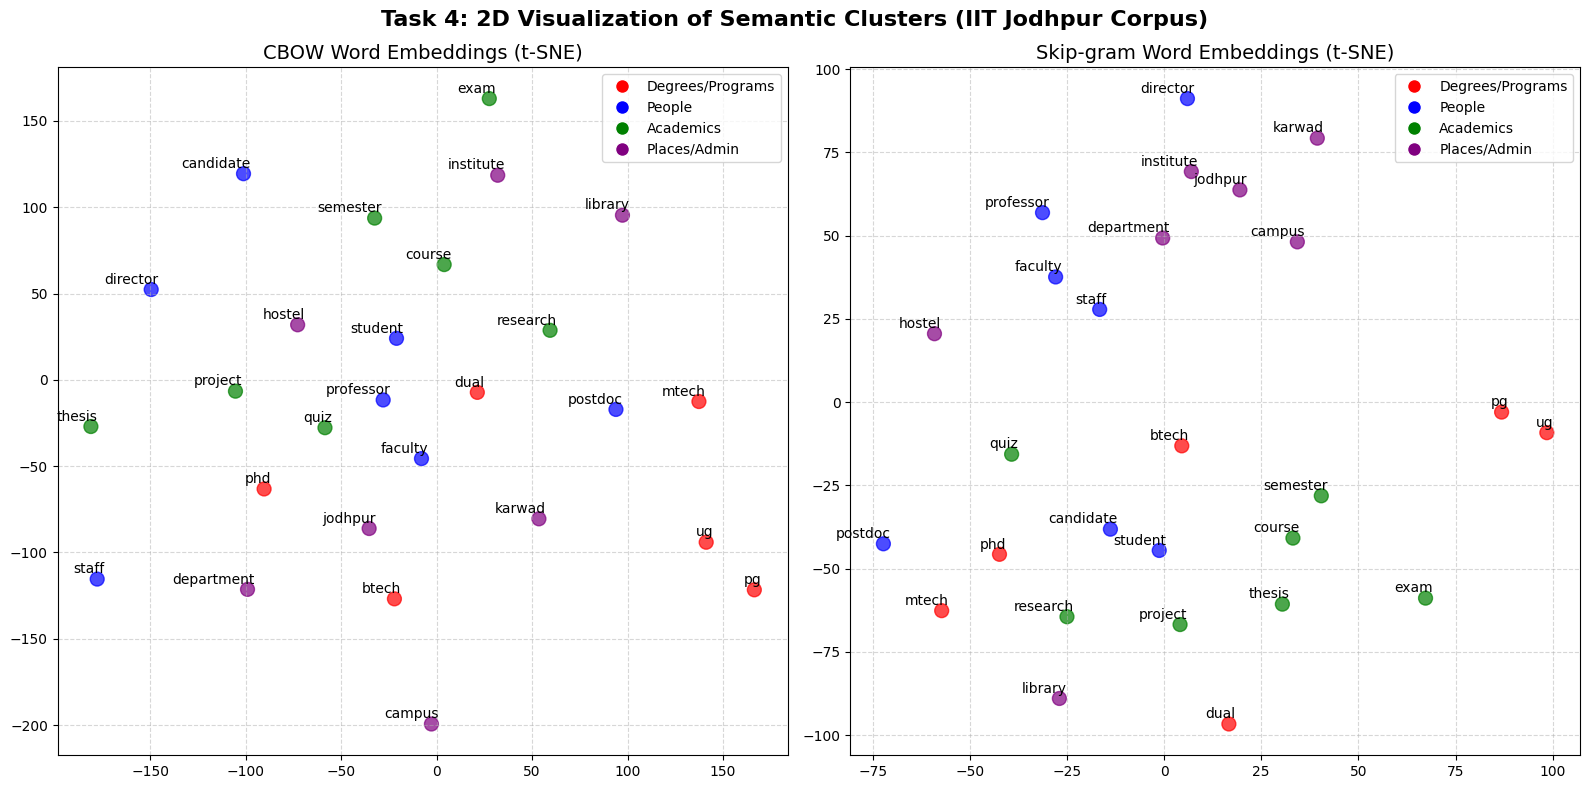

In [4]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np


#### TASK 4: VISUALIZATION (t-SNE) ####


print("Preparing to visualize word embeddings...")

# 1. Define logical categories (clusters) relevant to the IIT Jodhpur corpus
clusters = {
    'Degrees/Programs': ['btech', 'mtech', 'phd', 'ug', 'pg', 'dual'],
    'People': ['student', 'faculty', 'professor', 'director', 'candidate', 'postdoc', 'staff'],
    'Academics': ['research', 'exam', 'quiz', 'course', 'thesis', 'project', 'semester'],
    'Places/Admin': ['hostel', 'library', 'department', 'jodhpur', 'karwad', 'campus', 'institute']
}

# Consolidate words and assign colors for the plot
words_to_visualize = []
colors = []
color_map = ['red', 'blue', 'green', 'purple']

for i, (cluster_name, words) in enumerate(clusters.items()):
    for word in words:
        if word in word2idx: # Only include words that actually exist in our vocabulary
            words_to_visualize.append(word)
            colors.append(color_map[i])

# 2. Extract the specific vectors for the selected words
cbow_vectors = np.array([cbow_embeddings[word2idx[w]].numpy() for w in words_to_visualize])
sg_vectors = np.array([sg_embeddings[word2idx[w]].numpy() for w in words_to_visualize])

# 3. Apply t-SNE to reduce dimensionality from 50D down to 2D
# Perplexity is set low because we are only visualizing a small number of points
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca')

print("Running t-SNE for CBOW...")
cbow_2d = tsne.fit_transform(cbow_vectors)

print("Running t-SNE for Skip-gram...")
sg_2d = tsne.fit_transform(sg_vectors)

# 4. Plotting the results side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

def plot_embeddings(ax, embeddings_2d, title):
    """Helper function to plot the 2D scatter and annotate words."""
    ax.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=100, alpha=0.7)

    # Annotate each point with its corresponding word
    for i, word in enumerate(words_to_visualize):
        ax.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                    xytext=(5, 2), textcoords='offset points', ha='right', va='bottom', fontsize=10)

    # Add a custom legend
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor=color_map[i],
                              markersize=10, label=cluster) for i, cluster in enumerate(clusters.keys())]
    ax.legend(handles=legend_elements, loc='best')
    ax.set_title(title, fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

plot_embeddings(ax1, cbow_2d, "CBOW Word Embeddings (t-SNE)")
plot_embeddings(ax2, sg_2d, "Skip-gram Word Embeddings (t-SNE)")

plt.suptitle("Task 4: 2D Visualization of Semantic Clusters (IIT Jodhpur Corpus)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# **Miscellaneous**

In [5]:
# --- Dedicated 300D Vector Extraction ---
print("Training a dedicated 300D model to fulfill the assignment requirement...")

# Initialize a strict 300D Skip-gram model
sg_300 = SkipGramNegSampling(vocab_size, 300).to(device)
optimizer_300 = optim.Adam(sg_300.parameters(), lr=0.01)

# Train it just to embed the weights
sg_300.train()
for epoch in range(5):
    for target, context in sg_loader:
        target, context = target.to(device), context.to(device)
        neg_samples = get_negative_samples_batch(target.size(0), 5, device)

        optimizer_300.zero_grad()
        loss = sg_300(target, context, neg_samples)
        loss.backward()
        optimizer_300.step()

# Extract and format the specific word
word_choice = "btech"
if word_choice in word2idx:
    idx = word2idx[word_choice]
    # Pull the 300D weights
    vec = sg_300.target_embeddings.weight.data.cpu()[idx].tolist()

    # Format
    formatted_vector = f"{word_choice} - " + ", ".join([f"{v:.4f}" for v in vec])

    print("\n--- ACTUAL 300-Dimensional Vector Output ---")
    print(formatted_vector)
    print(f"\nVerification: This vector has exactly {len(vec)} numbers.")
else:
    print(f"'{word_choice}' is not in the vocabulary.")

Training a dedicated 300D model to fulfill the assignment requirement...

--- ACTUAL 300-Dimensional Vector Output ---
btech - -0.4506, -0.6837, -0.3990, -0.1025, 0.5790, -0.4327, 1.8961, 0.3862, 0.2116, -0.2522, 0.0345, -0.5984, 0.2737, -0.0690, -0.3022, 0.2565, 1.1619, 0.5945, 0.0175, 0.5244, 0.0072, -0.7146, 0.1584, 0.1478, -1.0673, 1.2253, 0.0129, -0.7139, 0.4783, 0.1823, 0.0910, -0.4587, -0.3008, 1.1132, -0.2936, -0.0941, 1.1210, -0.0502, 0.3731, 0.0162, 1.6166, -1.9525, -0.4488, 0.1356, 0.9423, 1.0580, 1.0657, 0.9550, 1.1870, 1.2244, 1.9831, -0.8816, 0.4793, 0.3038, 0.6094, -1.0853, -0.1182, 0.3309, -0.5577, -0.8956, 0.0859, -0.0377, 1.6031, 0.5323, 1.6784, -1.4802, 0.4958, -1.2607, 0.3655, 0.6820, -0.3772, 0.0294, -0.0599, 0.4433, -0.4741, -0.2195, -1.9040, 1.1690, -1.4241, -0.6536, 1.3160, 0.7826, 1.8751, -0.7495, -0.4046, -0.1360, 1.5729, 0.1030, -0.1333, -0.4186, -0.8405, 1.2351, 0.6766, 1.0058, -0.2580, -0.6670, -1.1715, 1.1185, 1.5947, -2.1418, -0.5055, 1.0295, 0.1522, 0.05

In [3]:
from collections import Counter

# Read the generated corpus
with open("corpus.txt", "r", encoding="utf-8") as f:
    text = f.read().split()

# Get the top 10 words
top_10 = Counter(text).most_common(10)

# Format as needed in the assignment
formatted_output = ", ".join([f"{word}, {freq}" for word, freq in top_10])

print("--- Top 10 Words Output ---")
print(formatted_output)

--- Top 10 Words Output ---
the, 9163, of, 8041, in, 3133, to, 3057, and, 2940, for, 2407, a, 2068, is, 1735, jodhpur, 1732, rti, 1603
